# BoundarySpatial CCI Analysis Demo

This notebook demonstrates the cell-cell interaction (CCI) analysis and flow field visualization capabilities of BoundarySpatial.

**Workflow:**
1. Load spatial transcriptomics data
2. Calculate ligand-receptor (LR) scores
3. Compute vector fields for CCI
4. Calculate divergence fields
5. Visualize flow patterns

---

## 1. Environment Setup

In [1]:
import BoundarySP_invasive_direction as id
import pandas as pd
import scanpy as sc
import os
import numpy as np
import matplotlib.pyplot as plt

# Set plotting style
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = [10, 8]

## 2. Data Loading

Load the preprocessed spatial transcriptomics data (h5ad format).

In [2]:
# Load spatial transcriptomics data
adata = sc.read_h5ad('../Data/1_HCC-1L.h5ad')

print(f"Data shape: {adata.shape}")
print(f"Number of spots: {adata.n_obs}")
print(f"Number of genes: {adata.n_vars}")
print(f"\nObservation columns: {adata.obs.columns.tolist()}")

Data shape: (2791, 33538)
Number of spots: 2791
Number of genes: 33538

Observation columns: ['in_tissue', 'array_row', 'array_col']


## 3. Ligand-Receptor Score Calculation

Calculate LR scores based on spatial proximity. The `distance` parameter defines the maximum distance (in micrometers) for considering cell-cell interactions.

In [3]:
# Calculate LR scores with spatial distance constraint
adata = id.LR_score(
    path="/data1/huanchangxiang/datasets/public_spatial/output/02preprocess/",
    sample="1_HCC-1L",
    distance=500  # Maximum interaction distance in micrometers
)

print("LR score calculation completed!")
print(f"Updated adata shape: {adata.shape}")

LR score calculation completed!
Updated adata shape: (2791, 33538)


## 4. Cell Group Assignment

Load cell group information for the spatial data.

In [4]:
# Load cell group assignments
simu_cell_group = id.input_group(
    group_path="../Data/",
    sample="1_HCC-1L",
    adata=adata
)

print(f"Cell group data shape: {simu_cell_group.shape}")
print(f"\nUnique labels: {simu_cell_group.obs['LabelNew'].unique()}")
print(f"\nLabel distribution:")
print(simu_cell_group.obs['LabelNew'].value_counts())

Cell group data shape: (2791, 33538)

Unique labels: ['Normal', 'Mal', 'Mal_500', 'Normal_900', 'Normal_400', ..., 'Normal_1000', 'Mal_1000', 'Normal_300', 'Normal_200', 'Normal_600']
Length: 23
Categories (23, object): ['Bdy', 'Mal', 'Mal_100', 'Mal_200', ..., 'Normal_700', 'Normal_800', 'Normal_900', 'Normal_1000']

Label distribution:
LabelNew
Normal         1069
Mal             571
Mal_100          68
Bdy              67
Mal_200          66
Mal_500          66
Mal_300          66
Mal_400          65
Mal_600          65
Normal_100       64
Mal_700          63
Mal_900          62
Mal_800          62
Mal_1000         61
Normal_200       58
Normal_300       46
Normal_400       42
Normal_1000      40
Normal_500       39
Normal_600       39
Normal_700       39
Normal_900       38
Normal_800       35
Name: count, dtype: int64


## 5. Vector Field Computation

Compute the vector field for cell-cell interactions using the CellPhoneDB database. We focus on the TGFB1-TGFBR3 ligand-receptor pair.

In [5]:
# Compute vector field for specific LR pair
results = id.vector_filed(
    adata=simu_cell_group,
    database="CellPhoneDB_v4.0",
    lr_pair=["TGFB1", "TGFBR3"]  # Focus on TGF-beta signaling
)

print("Vector field computation completed!")
print(f"Results type: {type(results)}")

Vector field computation completed!
Results type: <class 'list'>


## 6. Divergence Field Calculation

Calculate the divergence field to identify regions of convergence (sinks) and divergence (sources) in the CCI flow.

In [6]:
# Calculate divergence field on a grid
grid_x, grid_y, net_field, U, V = id.calculate_divergence_field_paired(
    results,
    adata=simu_cell_group,
    grid_res=60,  # Grid resolution
    sigma=5       # Gaussian smoothing parameter
)

print(f"Grid dimensions: {grid_x.shape}")
print(f"Vector field shape: {net_field.shape}")
print("Divergence field calculation completed!")

Grid dimensions: (60, 60)
Vector field shape: (60, 60)
Divergence field calculation completed!


## 7. Label Processing

Process the cell labels to group boundary-related regions together for clearer visualization.

In [7]:
# Define boundary-related labels
bdy_set = {'Mal_100', 'Bdy', 'Normal_100', 'Normal_200', 'Normal_300', 'Normal_400'}

# Process labels
labels = simu_cell_group.obs['LabelNew'].astype(str)
mask_bdy = labels.isin(bdy_set)

# Group boundary labels as 'Bdy'
labels[mask_bdy] = 'Bdy'

# Extract main category (Mal or Normal) for other labels
labels[~mask_bdy] = labels[~mask_bdy].str.extract(r'^(Mal|Normal)', expand=False).fillna('Unknown')

# Assign processed labels
simu_cell_group.obs['Label'] = labels.copy()

print("Label processing completed!")
print(f"\nProcessed label distribution:")
print(simu_cell_group.obs['Label'].value_counts())

Label processing completed!

Processed label distribution:
Label
Normal    1299
Mal       1147
Bdy        345
Name: count, dtype: int64


## 8. Flow Field Visualization

Visualize the CCI flow field overlaid on the spatial tissue structure.

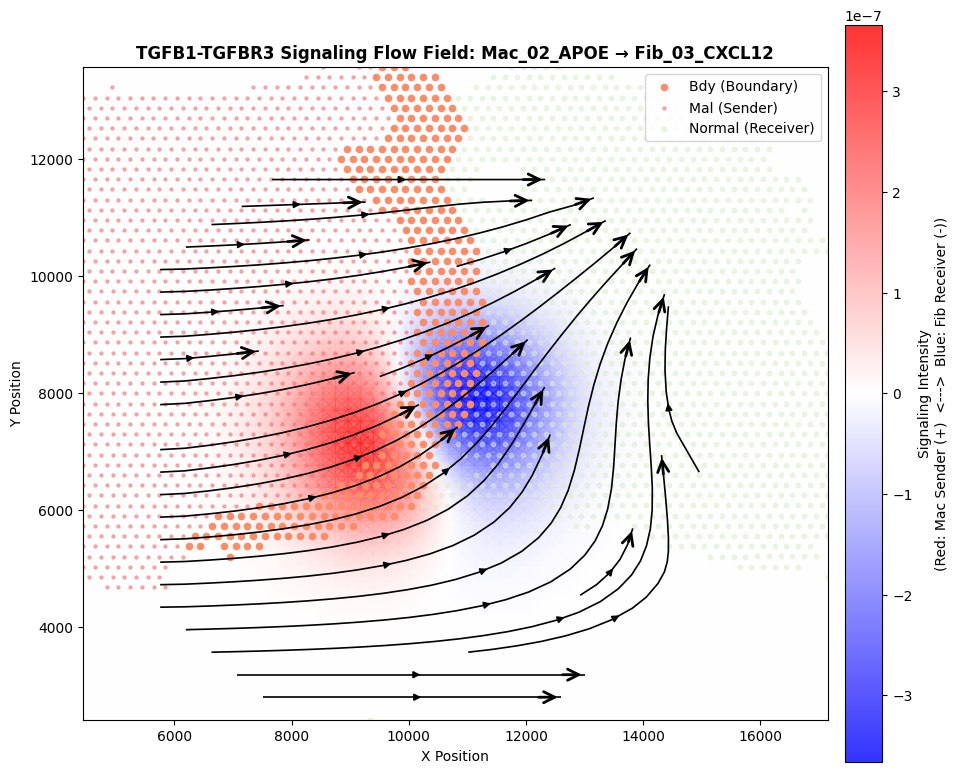


Figure saved to: ../Output/Boundaryspatial_predict_flow.pdf


In [8]:
# Plot flow field
id.plot_flow(
    adata=simu_cell_group,
    grid_x=grid_x,
    grid_y=grid_y,
    net_field=net_field,
    U=U,
    V=V
)

# Save figure
plt.savefig('../Output/Boundaryspatial_predict_flow.pdf', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print("\nFigure saved to: ../Output/Boundaryspatial_predict_flow.pdf")